# Lab 9 - Graph Data Analytics

Complete the code with TODO tag.

If you haven't installed networkx package, you can run the following command (note the exclamation mark)

```bash
!conda install networkx --yes
```

## 1. Centrality Analysis
In this exercise, you will implement the pagerank centrality.

C:\Users\Denis\AppData\Local\Temp\ipykernel_18524\1170187204.py:18: DeprecationWarning: info is deprecated and will be removed in version 3.0.

  print(nx.info(G))


Graph named "Zachary's Karate Club" with 34 nodes and 78 edges
Number of nodes:  78
Number of nodes:  34
Average degree: 4.5882 


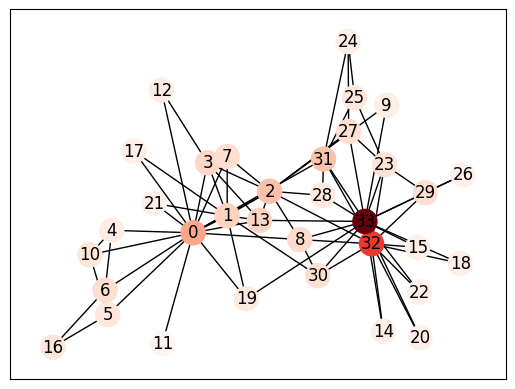

In [12]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

def pagerank_centrality(G, iter=100):
    p = np.array([1 for i in G.nodes()])
    
    for k in range(iter):
        for i in G.nodes():
            for j in G.nodes():
                p[i] += G.number_of_edges(i,j) * p[j] / G.degree[j]

        norm = sum(p)
        p = p / norm
    return p

G = nx.karate_club_graph()
print(nx.info(G))
print("Number of nodes: ", G.number_of_edges())
print("Number of nodes: ", G.number_of_nodes())
degrees = [val for (node, val) in G.degree()]
print("Average degree: {:.4f} ".format(sum(degrees)/G.number_of_nodes()))
values = pagerank_centrality(G)
nx.draw_networkx(G, cmap=plt.get_cmap('Reds'), node_color = values, with_labels=True)

## 2. Community Analysis

### 2.1. Clique Percolation Method

One well-known algorithm for detecting overlapping communities is called the Clique Percolation Method (CPM).

In [13]:
from itertools import combinations

def get_percolated_cliques(G, k):
    perc_graph = nx.Graph()
    
    cliques = list(frozenset(c) for c in nx.find_cliques(G) if len(c) >= k)
    perc_graph.add_nodes_from(cliques)

    for c1, c2 in combinations(cliques, 2):
        if len(c1.intersection(c2)) >= (k-1):
            perc_graph.add_edge(c1,c2)

    for component in nx.connected_components(perc_graph):
        yield(frozenset.union(*component))

Test with a small dataset

Graph named "Zachary's Karate Club" with 34 nodes and 78 edges
Number of nodes:  78
Number of nodes:  34
Average degree: 4.5882 
---0.0 seconds---


C:\Users\Denis\AppData\Local\Temp\ipykernel_18524\3538212382.py:12: DeprecationWarning: info is deprecated and will be removed in version 3.0.

  print(nx.info(G))


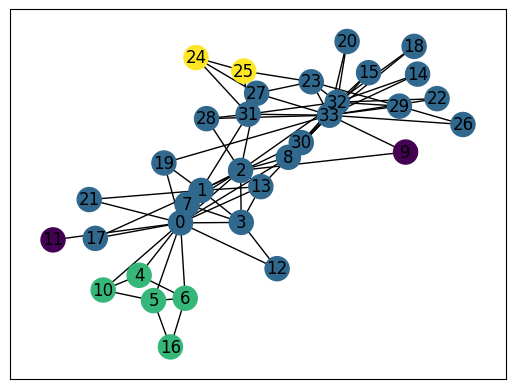

In [14]:
def partition(communities):
    node2communities = dict()
    
    for counter, clique in enumerate(communities):
        for node in clique:
            if node not in node2communities:
                node2communities[node] = []
            node2communities[node] += [counter]
    return node2communities

G = nx.karate_club_graph()
print(nx.info(G))
print("Number of nodes: ", G.number_of_edges())
print("Number of nodes: ", G.number_of_nodes())
degrees = [val for (node, val) in G.degree()]
print("Average degree: {:.4f} ".format(sum(degrees)/G.number_of_nodes()))

import time
start_time = time.time()
communities = get_percolated_cliques(G,3)
print("---{0} seconds---".format(time.time() - start_time))
part = partition(communities)
values = [part.get(node,[-1])[0] for node in G.nodes()]

nx.draw_networkx(G, node_color = values, with_labels=True)

### 2.2. Efficient Implementation
That implementation is correct but expensive---it requires O(N^2) clique comparisons, where N is the number of cliques (which is often much larger than the number of nodes!).  If we use a python dictionary to index which nodes belong to which cliques, then we can easily compare only those cliques that share at least one node in common.  This implementation is a bit longer but should be more efficient:

---0.0 seconds---


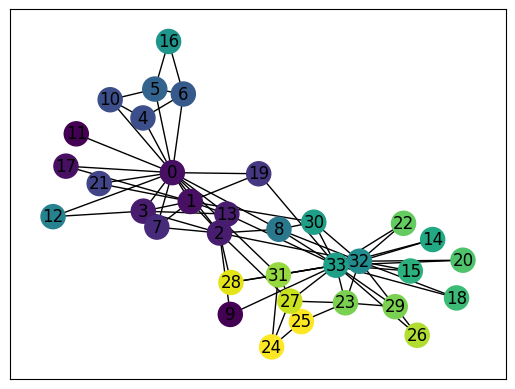

In [15]:
from collections import defaultdict

def get_percolated_cliques2(G, k):
    perc_graph = nx.Graph()
    cliques = [frozenset(c) for c in nx.find_cliques(G) if len(c) >= k]
    perc_graph.add_nodes_from(cliques)

    membership_dict = defaultdict(list)
    for clique in cliques:
        for node in clique:
            membership_dict[node].append(clique)

    for clique in cliques:
        for adj_clique in get_adjacent_cliques(clique, membership_dict):
            if len(clique.intersection(adj_clique)) >= (k - 1):
                perc_graph.add_edge(clique, adj_clique)

    for component in nx.connected_components(perc_graph):
        yield(frozenset.union(*component))

def get_adjacent_cliques(clique, membership_dict):
    adjacent_cliques = set()
    return adjacent_cliques

start_time = time.time()
communities = get_percolated_cliques2(G,3)
print("---{0} seconds---".format(time.time() - start_time))
part = partition(get_percolated_cliques2(G,3))

values = [part.get(node,[-1])[0] for node in G.nodes()]

nx.draw_networkx(G, node_color = values, with_labels=True)

### 2.3. Test with large dataset

Now we test with a real large-scale network data at https://snap.stanford.edu/data/com-Amazon.html

In [17]:
# G = nx.read_edgelist("email-Eu-core.txt")
G = nx.read_edgelist('com-amazon.ungraph.txt')
print(nx.info(G))
print("Number of nodes: ", G.number_of_edges())
print("Number of nodes: ", G.number_of_nodes())
degrees = [val for (node, val) in G.degree()]
print("Average degree: {:.4f} ".format(sum(degrees)/G.number_of_nodes()))

start_time = time.time()
communities = get_percolated_cliques(G, 3)
print("---{0} seconds---".format(time.time() - start_time))

start_time = time.time()
communities = get_percolated_cliques2(G, 3)
print("---{0} seconds---".format(time.time() - start_time))

C:\Users\Denis\AppData\Local\Temp\ipykernel_18524\885257009.py:3: DeprecationWarning: info is deprecated and will be removed in version 3.0.

  print(nx.info(G))


Graph with 334863 nodes and 925872 edges
Number of nodes:  925872
Number of nodes:  334863
Average degree: 5.5299 
---0.0 seconds---
---0.0 seconds---
